In [1]:
from pathlib import Path
import os
import sys 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path().resolve().parent
sys.path.append(str(ROOT/"src"))
RAW_DATA_FILE = ROOT/'src'/'data'/'raw'/'loan_dataset_20000.csv'
print(ROOT)
print(RAW_DATA_FILE)

from utils.graficos import *

/home/jair/Proyectos/Loan_Status_Prediction
/home/jair/Proyectos/Loan_Status_Prediction/src/data/raw/loan_dataset_20000.csv


In [2]:
df = pd.read_csv(RAW_DATA_FILE)
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


## Análisis de los datos

In [3]:
variable_objetivo = 'loan_paid_back'
print(df.shape)
df.info()

(20000, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of_

In [4]:
df.describe()

,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,48.027000,43549.637765,3629.136466,0.177019,679.25695,15129.300909,12.400627,43.22280,455.625794,5.011800,48649.824769,24333.394631,1.990150,0.061800,2.489150,0.799900
std,15.829352,28668.579671,2389.048326,0.105059,69.63858,8605.405513,2.442729,11.00838,274.622125,2.244529,32423.378128,22313.845395,1.474945,0.285105,1.631384,0.400085
min,21.000000,6000.000000,500.000000,0.010000,373.00000,500.000000,3.140000,36.00000,9.430000,0.000000,6157.800000,496.350000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,24260.752500,2021.730000,0.096000,632.00000,8852.695000,10.740000,36.00000,253.910000,3.000000,27180.492500,9592.572500,1.000000,0.000000,1.000000,1.000000
50%,48.000000,36585.260000,3048.770000,0.160000,680.00000,14946.170000,12.400000,36.00000,435.595000,5.000000,40241.615000,18334.555000,2.000000,0.000000,2.000000,1.000000
75%,62.000000,54677.917500,4556.495000,0.241000,727.00000,20998.867500,14.002500,60.00000,633.595000,6.000000,60361.257500,31743.327500,3.000000,0.000000,3.000000,1.000000
max,75.000000,400000.000000,33333.330000,0.667000,850.00000,49039.690000,22.510000,60.00000,1685.400000,15.000000,454394.190000,352177.900000,11.000000,2.000000,11.000000,1.000000


### Separación del tipo de variables

In [5]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoric_cols = [col for col in df.columns if col not in numeric_cols]

print('Numéricas')
print(numeric_cols)
print(f'total: {len(numeric_cols)}')
print('Categóricas')
print(categoric_cols)
print(f'total: {len(categoric_cols)}')

Numéricas
['age', 'annual_income', 'monthly_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_term', 'installment', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'public_records', 'num_of_delinquencies', 'loan_paid_back']
total: 16
Categóricas
['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
total: 6


### Corrección del tipo de columnas

In [6]:
real_categoric = ['loan_term', 'public_records']
numeric_cols = [col for col in numeric_cols if col not in real_categoric]
categoric_cols = categoric_cols + real_categoric

print('Numéricas')
print(numeric_cols)
print(f'total: {len(numeric_cols)}')
print('Categóricas')
print(categoric_cols)
print(f'total: {len(categoric_cols)}')

Numéricas
['age', 'annual_income', 'monthly_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'installment', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'num_of_delinquencies', 'loan_paid_back']
total: 14
Categóricas
['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade', 'loan_term', 'public_records']
total: 8


### Distribución numéricas

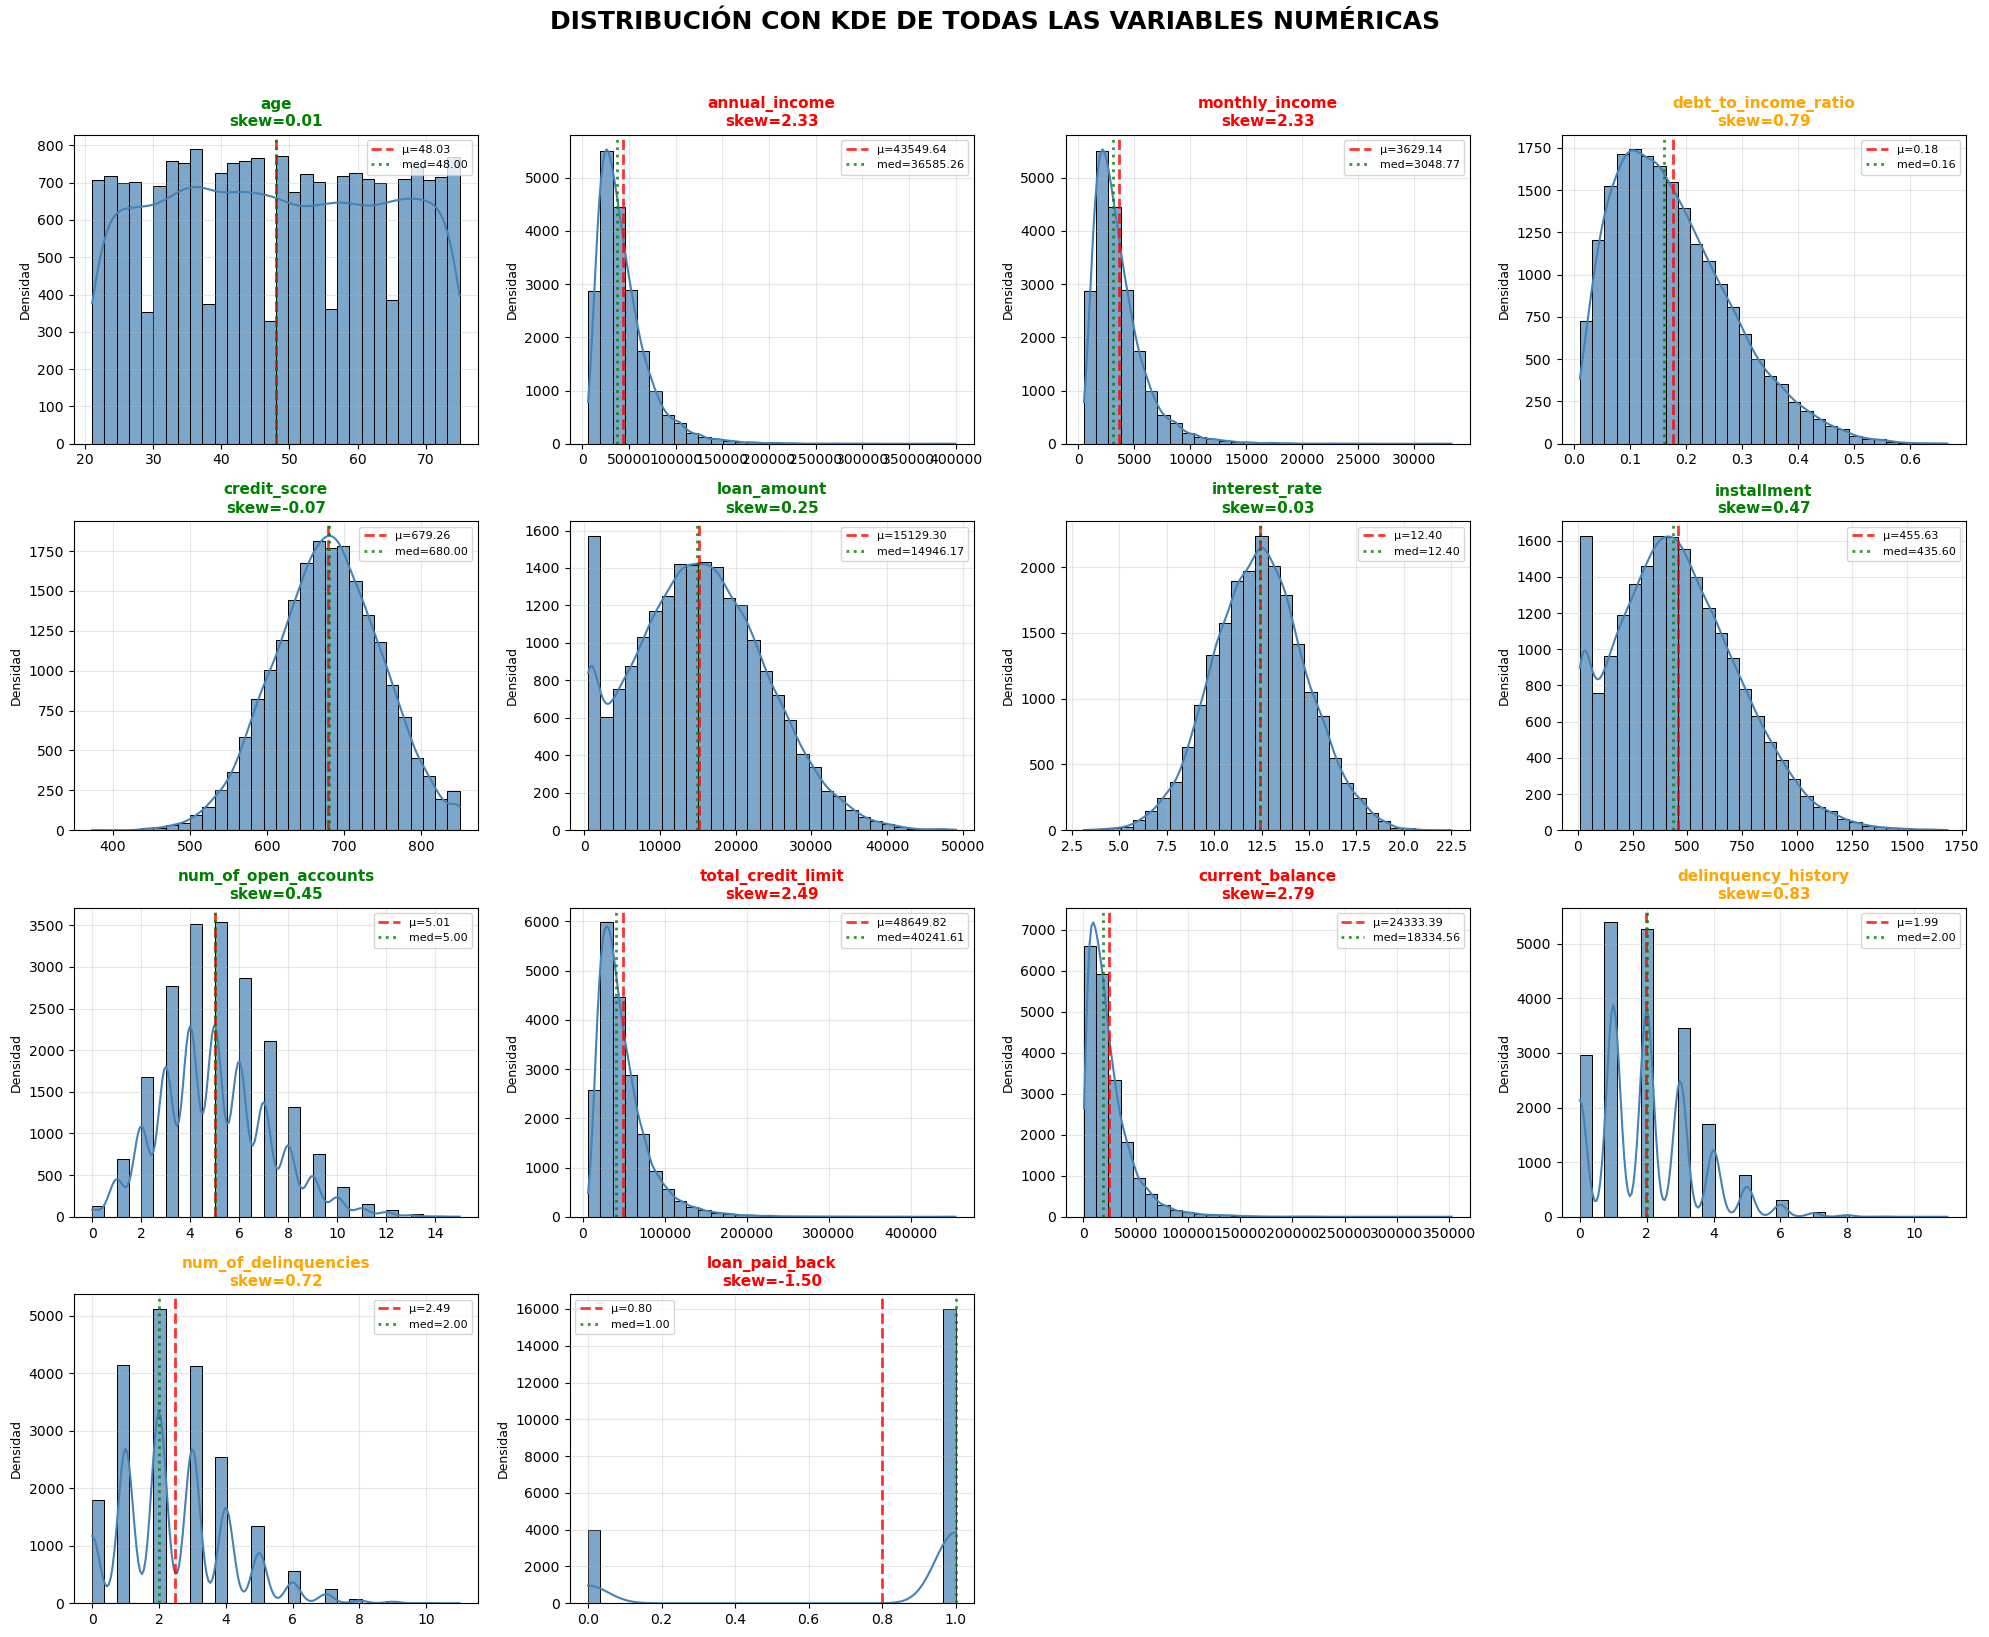

In [10]:
plot_distribuciones_kde(df, numeric_cols)

### Boxplots

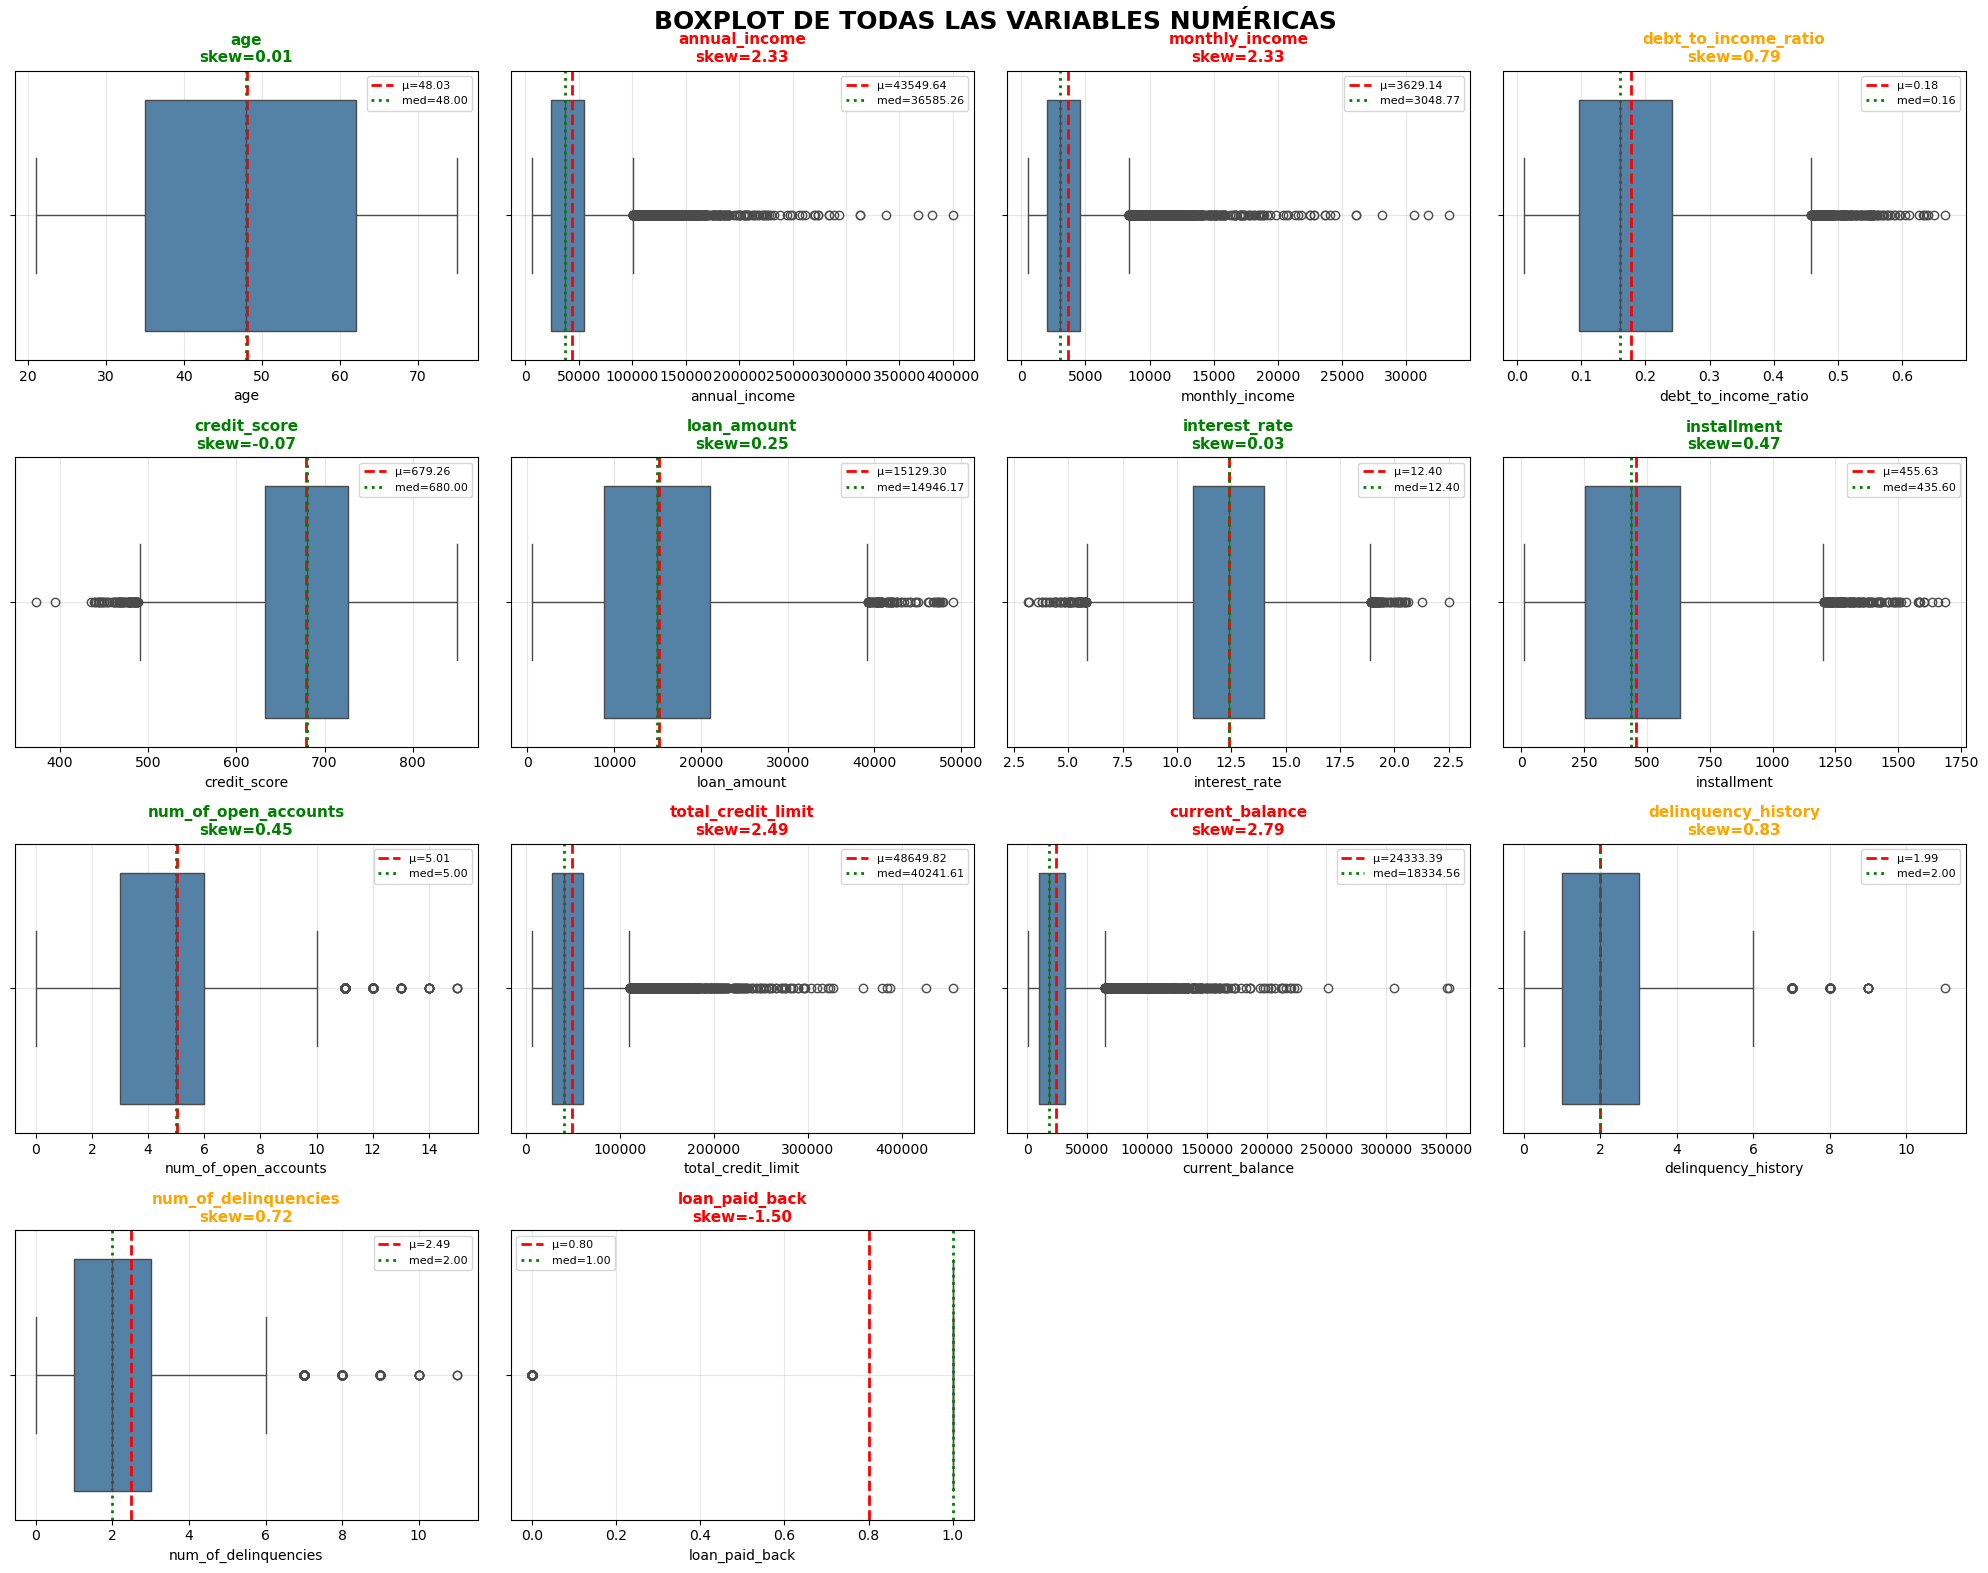

In [ ]:
box_plots(df, numeric_cols)

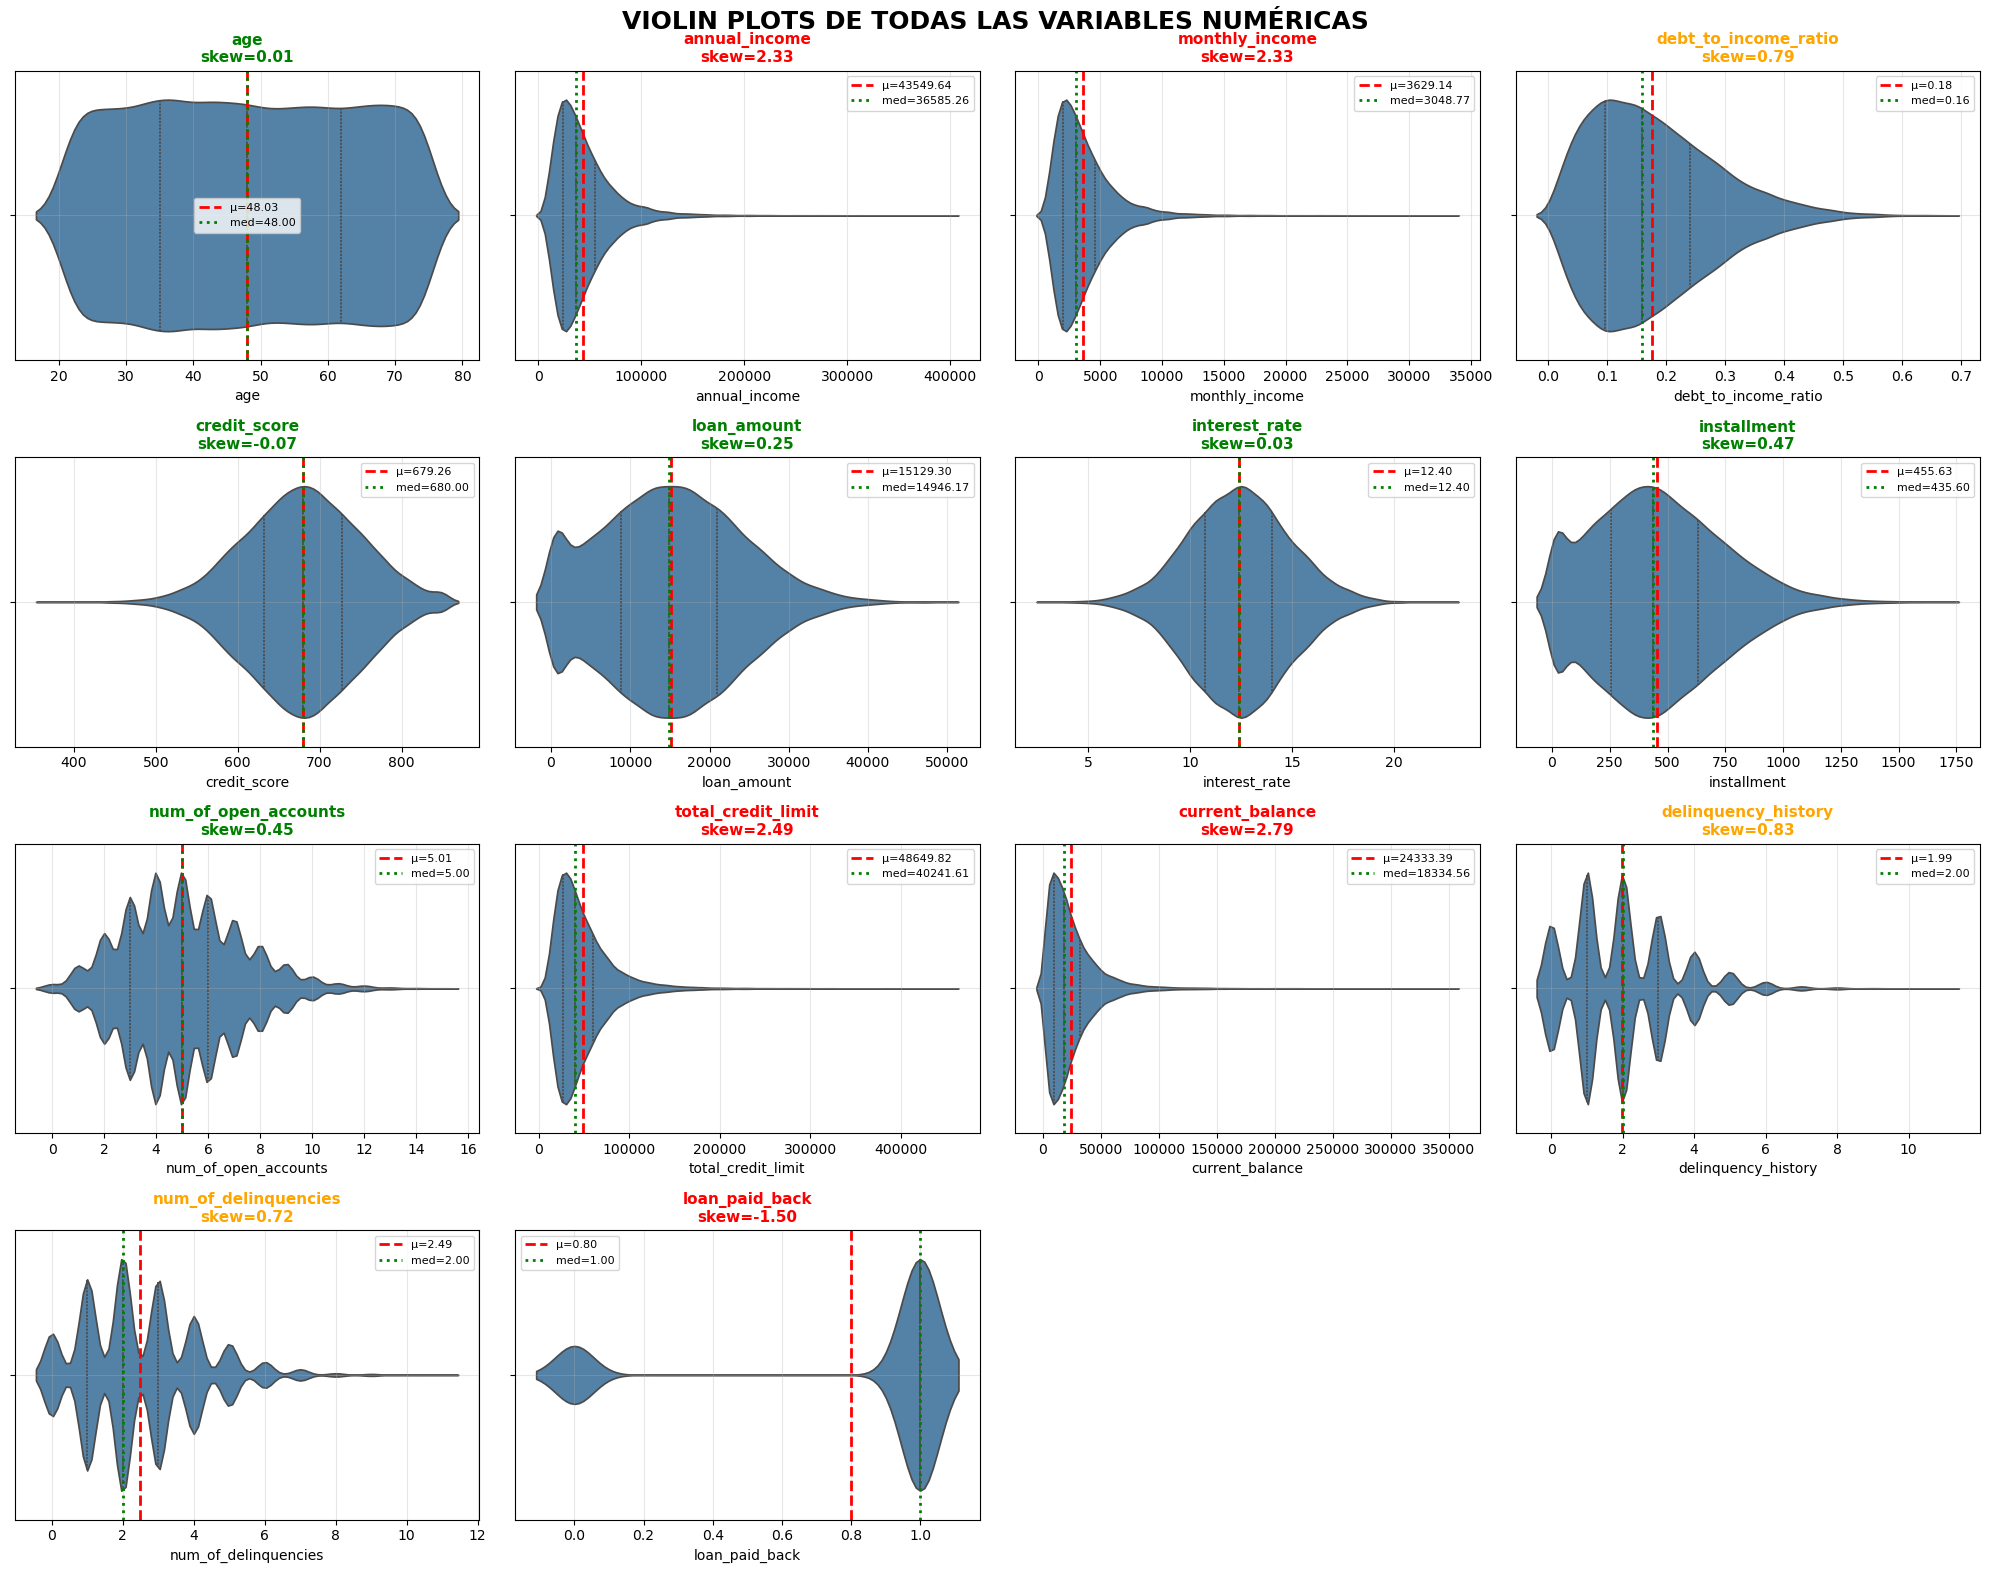

In [ ]:
violin_plots(df, numeric_cols)

### Variable objetivo

/home/jair/Proyectos/Loan_Status_Prediction/src/utils/graficos.py:183: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/home/jair/Proyectos/Loan_Status_Prediction/src/utils/graficos.py:197: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([negative_tick, positive_tick])


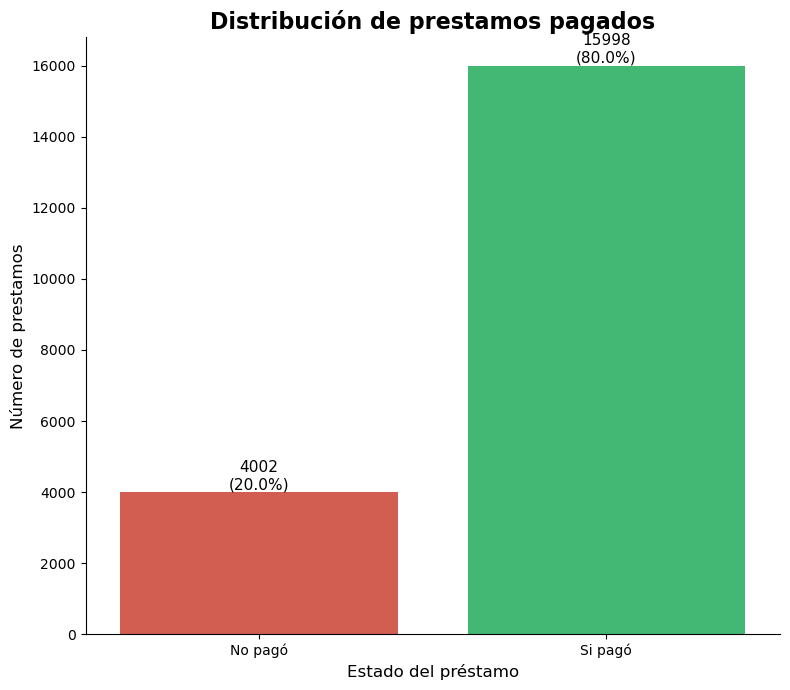

In [ ]:
histograma_variable_binaria(df, variable_objetivo, 'Estado del préstamo', 'Número de prestamos', 'Si pagó', 'No pagó', 'Distribución de prestamos pagados')

### Proporción de pago por nivel educativo

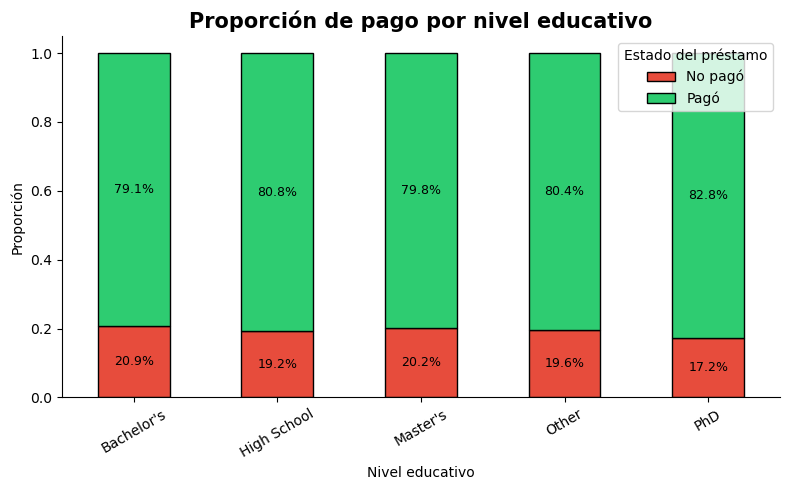

In [8]:
plot_crosstab_categorica(
    df,
    'education_level',
    variable_objetivo,
    titulo='Proporción de pago por nivel educativo',
    xlabel='Nivel educativo'
)

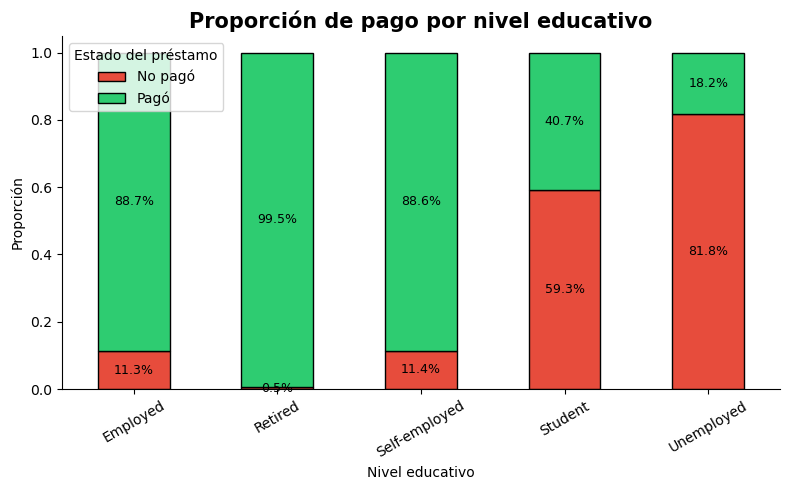

In [13]:
plot_crosstab_categorica(
    df,
    'employment_status',
    variable_objetivo,
    titulo='Proporción de pago por nivel educativo',
    xlabel='Nivel educativo'
)

### Análisis multivariado con el target

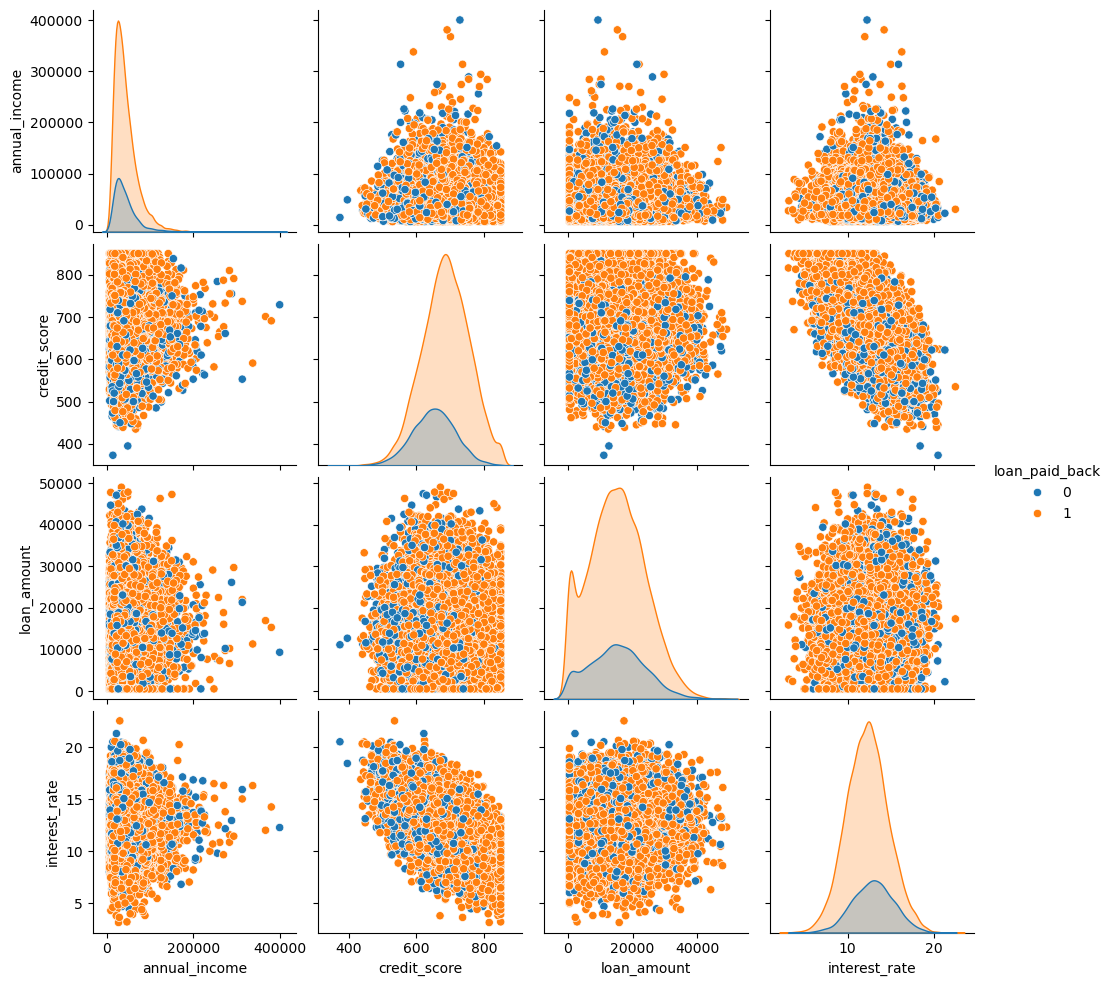

In [ ]:
sns.pairplot(df, vars=['annual_income', 'credit_score', 'loan_amount', 'interest_rate'], 
             hue='loan_paid_back', diag_kind='kde')
plt.show()

### Matriz de correlación

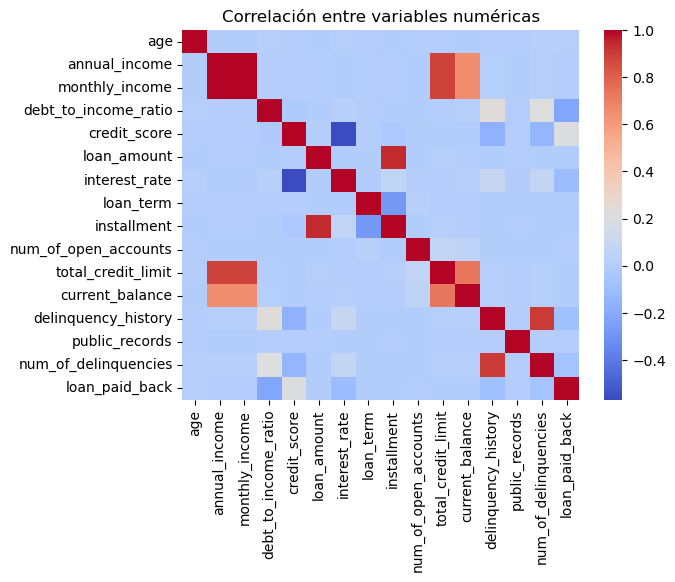

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlación entre variables numéricas')
plt.show()

### Diferencia de medias estandarizada

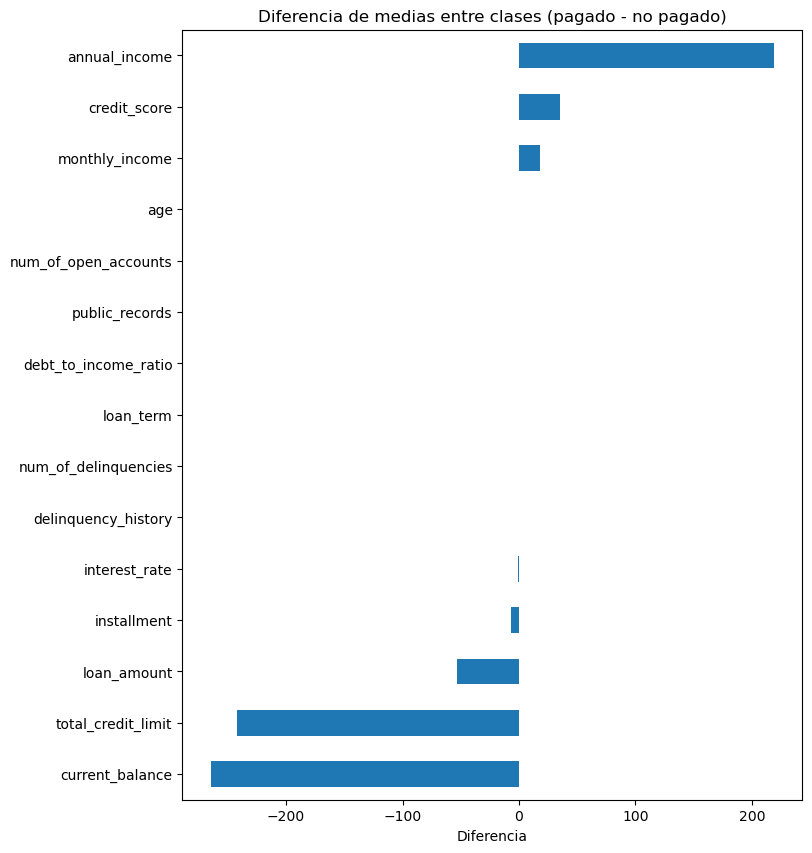

In [ ]:
diff_means = df.groupby('loan_paid_back').mean(numeric_only=True).T
diff_means['diferencia'] = diff_means[1] - diff_means[0]
diff_means['diferencia'].sort_values().plot(kind='barh', figsize=(8, 10))
plt.title('Diferencia de medias entre clases (pagado - no pagado)')
plt.xlabel('Diferencia')
plt.show()